# Fruit & Veg Demand Forecasting Model
## Foodland Wudinna — LightGBM Pipeline (v2)

**Purpose:** Predict daily sales quantity per item to generate accurate order lists.

**Order Formula:**
```
Order Qty = Coverage Demand + Depletion Demand − Stock on Hand
```

| Cycle | Order Day | Delivery | Depletion (gap) | Coverage |
|-------|-----------|----------|-----------------|----------|
| A | Wednesday | Friday AM | Wed afternoon (×0.42) + Thursday | Fri + Sat + Mon |
| B | Friday | Tuesday AM | Fri afternoon (×0.42) + Sat + Mon | Tue + Wed + Thu |

**How to use this notebook:**
1. Export latest POS data and update `sales_fruit_2026.csv`
2. Update `specials_this_week.csv` with items on special (or leave empty)
3. Set `ORDER_CYCLE` below to `'wednesday'` or `'friday'`
4. **Run All Cells** (Cell → Run All)
5. Fill manual stock counts into `01_data/operational/stock_on_hand_v2.csv` (SOH column)
6. Re-run cells from Section 13 onwards
7. Open the generated Excel file — that's your order

**Requirements:** `pip install pandas numpy lightgbm scikit-learn matplotlib openpyxl`

---
*Place data files in the same folder as this notebook.*

## 1. Setup & Configuration

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

# ── CONFIGURATION ──────────────────────────────────────────────────
# Which ordering cycle are we running?
ORDER_CYCLE = 'wednesday'  # <-- CHANGE to 'friday' when ordering on Friday

# Which forecast model to use for the order list?
USE_MODEL = 'ewma'  # <-- 'ewma' (recommended) or 'lgbm'

# Trading hours
WEEKDAY_HOURS = 9.5   # 08:30 - 18:00
SATURDAY_HOURS = 4.0  # 08:00 - 12:00
AFTERNOON_HOURS = 4.0 # hours remaining after midday stock count
WEEKDAY_AFTERNOON_FRACTION = AFTERNOON_HOURS / WEEKDAY_HOURS  # ≈ 0.42

# Minimum lines in 2026 to count as an active item
MIN_LINES_2026 = 10

ROOT = Path('..').resolve()  # = foodland_wudinna/

# ── SA PUBLIC HOLIDAYS — loaded from reference file ──────────────────
_hol_file = ROOT / '01_data/reference/sa_holidays_prophet.csv'
if _hol_file.exists():
    _hol_df = pd.read_csv(_hol_file, parse_dates=['ds'])
    PUBLIC_HOLIDAYS = set(_hol_df['ds'].dt.normalize())
else:
    # Fallback: hardcoded SA public holidays 2025-2026
    PUBLIC_HOLIDAYS = {pd.Timestamp(d) for d in [
        '2025-01-01','2025-01-27','2025-03-10','2025-04-18','2025-04-21',
        '2025-04-25','2025-06-09','2025-10-06','2025-12-25','2025-12-26',
        '2026-01-01','2026-01-26','2026-03-09','2026-04-03','2026-04-06',
        '2026-04-25','2026-06-08','2026-10-05','2026-12-25','2026-12-26',
    ]}

print(f"Order cycle:    {ORDER_CYCLE.upper()}")
print(f"Forecast model: {USE_MODEL.upper()}")
print(f"Weekday afternoon fraction: {WEEKDAY_AFTERNOON_FRACTION:.2f}")
print(f"Public holidays loaded: {len(PUBLIC_HOLIDAYS)}")

Order cycle:    WEDNESDAY
Forecast model: EWMA
Weekday afternoon fraction: 0.42
Public holidays loaded: 26


## 2. Load & Clean Data

In [2]:
# Load POS data
df25 = pd.read_csv(ROOT / '01_data/raw/sales_fruit_2025.csv', parse_dates=['Date'])
df26 = pd.read_csv(ROOT / '01_data/raw/sales_fruit_2026.csv', parse_dates=['Date'])
df = pd.concat([df25, df26], ignore_index=True)

print(f"2025: {df25['Date'].min().date()} to {df25['Date'].max().date()} ({df25['Date'].nunique()} trading days)")
print(f"2026: {df26['Date'].min().date()} to {df26['Date'].max().date()} ({df26['Date'].nunique()} trading days)")
print(f"Total records: {len(df):,}")

# Clean: remove waste/markdown items and negative quantities
clean = df[
    (~df['Name'].str.contains('REDUCED|CLEARANCE|MARKDOWN', case=False, na=False)) &
    (df['Quantity'] > 0)
].copy()

clean['year'] = clean['Date'].dt.year
clean['dow'] = clean['Date'].dt.dayofweek

# Flag public holidays
clean['is_holiday'] = clean['Date'].isin(PUBLIC_HOLIDAYS).astype(int)
holidays_in_data = clean[clean['is_holiday'] == 1]['Date'].nunique()
print(f"Clean records: {len(clean):,}")
print(f"Public holidays found in data: {holidays_in_data}")

2025: 2025-01-02 to 2025-12-31 (308 trading days)
2026: 2026-01-01 to 2026-04-01 (77 trading days)
Total records: 40,114
Clean records: 39,833
Public holidays found in data: 3


## 3. Wednesday Specials Detection

Specials cause 2-5x demand spikes. We detect them by looking for cycles where an item's GP%
drops more than 15 points below its baseline median, with at least 2 transactions in the cycle.

In [3]:
# Wednesday cycle alignment
clean['days_since_wed'] = (clean['dow'] - 2) % 7
clean['cycle_start'] = clean['Date'] - pd.to_timedelta(clean['days_since_wed'], unit='D')

# Each item's baseline GP%
item_median_gp = clean.groupby('Name')['GP %'].median().rename('baseline_gp')
clean = clean.merge(item_median_gp, on='Name', how='left')

# Cycle-level aggregation
cycle_gp = clean.groupby(['Name', 'cycle_start']).agg(
    cycle_median_gp=('GP %', 'median'),
    cycle_txns=('Lines', 'sum'),
    baseline_gp=('baseline_gp', 'first')
).reset_index()

cycle_gp['is_special'] = (
    (cycle_gp['baseline_gp'] - cycle_gp['cycle_median_gp'] > 15) &
    (cycle_gp['cycle_txns'] >= 2)
)

specials_lookup = set(
    zip(cycle_gp[cycle_gp['is_special']]['Name'],
        cycle_gp[cycle_gp['is_special']]['cycle_start'])
)

clean['on_special'] = clean.apply(
    lambda r: (r['Name'], r['cycle_start']) in specials_lookup, axis=1
).astype(int)

print(f"Special cycles detected: {cycle_gp['is_special'].sum()} ({cycle_gp['is_special'].mean()*100:.1f}% of all item-cycles)")

Special cycles detected: 559 (5.7% of all item-cycles)


## 4. Build Daily Demand Matrix

In [4]:
# Active items
item_lines_26 = clean[clean['year'] == 2026].groupby('Name')['Lines'].sum()
active_items = item_lines_26[item_lines_26 >= MIN_LINES_2026].index.tolist()
print(f"Active items: {len(active_items)}")

# Aggregate daily demand per item
daily = clean[clean['Name'].isin(active_items)].groupby(['Date', 'Name']).agg(
    qty=('Quantity', 'sum'),
    lines=('Lines', 'sum'),
    revenue=('Sales Ex GST', 'sum'),
    gp_pct=('GP %', 'median'),
    on_special=('on_special', 'max'),
    is_holiday=('is_holiday', 'max')
).reset_index()
# Sell price per unit — used for price_ratio feature
daily['sell_price_pu'] = (daily['revenue'] / daily['qty'].clip(lower=0.001)).round(4)

daily['dow'] = daily['Date'].dt.dayofweek
daily['year'] = daily['Date'].dt.year

# Full grid
trading_dates = sorted(clean['Date'].unique())
grid = pd.MultiIndex.from_product([trading_dates, active_items], names=['Date', 'Name'])
daily_full = daily.set_index(['Date', 'Name']).reindex(grid, fill_value=0).reset_index()
daily_full['dow'] = daily_full['Date'].dt.dayofweek
daily_full['year'] = daily_full['Date'].dt.year
daily_full['is_holiday'] = daily_full['Date'].isin(PUBLIC_HOLIDAYS).astype(int)

print(f"Full grid: {len(daily_full):,} rows ({len(active_items)} items × {len(trading_dates)} days)")

Active items: 189
Full grid: 72,765 rows (189 items × 385 days)


## 5. Feature Engineering (28 features)

All features derived from EDA findings, now including **public holiday flag**.

In [5]:
# ── Calendar features ──
daily_full['month'] = daily_full['Date'].dt.month
daily_full['week_of_year'] = daily_full['Date'].dt.isocalendar().week.astype(int)
daily_full['day_of_month'] = daily_full['Date'].dt.day
daily_full['days_since_wed'] = (daily_full['dow'] - 2) % 7
daily_full['is_saturday'] = (daily_full['dow'] == 5).astype(int)
daily_full['is_friday'] = (daily_full['dow'] == 4).astype(int)
daily_full['is_monday'] = (daily_full['dow'] == 0).astype(int)

# ── Item-level statistics ──
item_stats = daily_full[daily_full['is_holiday'] == 0].groupby('Name').agg(
    item_avg_qty=('qty', 'mean'),
    item_std_qty=('qty', 'std'),
    item_max_qty=('qty', 'max'),
    item_avg_lines=('lines', 'mean'),
    item_pct_zero=('qty', lambda x: (x == 0).mean())
).reset_index()
item_stats['item_std_qty'] = item_stats['item_std_qty'].fillna(0)
daily_full = daily_full.merge(item_stats, on='Name', how='left')

# ── Item × DOW interaction ──
item_dow = daily_full[daily_full['is_holiday'] == 0].groupby(['Name', 'dow'])['qty'].mean().reset_index()
item_dow.columns = ['Name', 'dow', 'item_dow_avg']
daily_full = daily_full.merge(item_dow, on=['Name', 'dow'], how='left')

# ── Same-weekday lags (excluding holidays from lag computation) ──
daily_full = daily_full.sort_values(['Name', 'dow', 'Date'])
for lag in [1, 2, 3, 4, 5, 6]:
    daily_full[f'sdow_lag{lag}'] = daily_full.groupby(['Name', 'dow'])['qty'].shift(lag)

# ── Same-weekday moving averages ──
daily_full['sdow_ma4'] = daily_full[['sdow_lag1', 'sdow_lag2', 'sdow_lag3', 'sdow_lag4']].mean(axis=1)
daily_full['sdow_ma6'] = daily_full[[f'sdow_lag{i}' for i in range(1, 7)]].mean(axis=1)

# ── EWMA (alpha=0.7) ──
alpha = 0.7
ew = np.array([alpha ** i for i in range(6)])
ew = ew / ew.sum()

lag_cols = [f'sdow_lag{i}' for i in range(1, 7)]
lag_matrix = daily_full[lag_cols].values
available = ~np.isnan(lag_matrix)
lag_filled = np.nan_to_num(lag_matrix, nan=0.0)
weighted_sum = lag_filled @ ew
weight_sum = available @ ew
daily_full['sdow_ewma'] = np.where(weight_sum > 0, weighted_sum / weight_sum, daily_full['item_dow_avg'])

# ── Coefficient of variation ──
daily_full['sdow_cv'] = (
    daily_full[['sdow_lag1', 'sdow_lag2', 'sdow_lag3', 'sdow_lag4']].std(axis=1) /
    daily_full[['sdow_lag1', 'sdow_lag2', 'sdow_lag3', 'sdow_lag4']].mean(axis=1).clip(lower=0.1)
).fillna(1.0).clip(upper=5.0)

# ── Trend ──
daily_full['sdow_trend'] = (daily_full['sdow_lag1'] - daily_full['sdow_lag2']).fillna(0)

# ── Specials flag per cycle ──
daily_full['cycle_start'] = daily_full['Date'] - pd.to_timedelta((daily_full['dow'] - 2) % 7, unit='D')
cycle_specials = clean.groupby(['Name', 'cycle_start'])['on_special'].max().reset_index()
cycle_specials.columns = ['Name', 'cycle_start', 'cycle_on_special']
daily_full = daily_full.merge(cycle_specials, on=['Name', 'cycle_start'], how='left')
daily_full['cycle_on_special'] = daily_full['cycle_on_special'].fillna(0)

# ── Season ──
season_map = {1: 3, 2: 3, 3: 3, 4: 2, 5: 2, 6: 1, 7: 1, 8: 1, 9: 2, 10: 2, 11: 3, 12: 3}
daily_full['season'] = daily_full['month'].map(season_map).fillna(2)

# ── Price ratio ──
daily_full = daily_full.sort_values(['Name', 'Date'])
daily_full['roll_avg_price'] = (
    daily_full.groupby('Name')['sell_price_pu']
    .transform(lambda x: x.shift(1).rolling(window=8*7, min_periods=5).mean())
)
daily_full['price_ratio'] = (
    daily_full['sell_price_pu'] / daily_full['roll_avg_price'].clip(lower=0.01)
).clip(lower=0.3, upper=3.0).fillna(1.0)

# ── Price sensitivity flag ──
SENSITIVITY_FILE = ROOT / '01_data/reference/item_price_sensitivity.csv'
if SENSITIVITY_FILE.exists():
    sens_df = pd.read_csv(SENSITIVITY_FILE)[['Name', 'is_price_sensitive']]
    daily_full = daily_full.merge(sens_df, on='Name', how='left')
    daily_full['is_price_sensitive'] = daily_full['is_price_sensitive'].fillna(0).astype(int)
    print(f"Price-sensitive items in training data: {daily_full['is_price_sensitive'].sum() / len(daily_full) * 100:.1f}% of rows")
else:
    daily_full['is_price_sensitive'] = 0
    print('item_price_sensitivity.csv not found — is_price_sensitive set to 0')

# Feature list (29 features)
feature_cols = [
    'dow', 'month', 'day_of_month', 'days_since_wed', 'is_saturday', 'is_friday', 'is_monday',
    'is_holiday',
    'item_avg_qty', 'item_std_qty', 'item_max_qty', 'item_avg_lines', 'item_pct_zero',
    'item_dow_avg',
    'sdow_lag1', 'sdow_lag2', 'sdow_lag3', 'sdow_lag4', 'sdow_lag5', 'sdow_lag6',
    'sdow_ma4', 'sdow_ma6', 'sdow_ewma',
    'sdow_cv', 'sdow_trend',
    'cycle_on_special', 'season',
    'price_ratio', 'is_price_sensitive'
]

print(f"Features: {len(feature_cols)}")
print(f"Model-ready rows: {daily_full.dropna(subset=['sdow_ma4']).shape[0]:,}")

Price-sensitive items in training data: 31.2% of rows
Features: 29
Model-ready rows: 71,442


## 6. Train / Validation / Test Split

In [6]:
from datetime import timedelta

model_data = daily_full.dropna(subset=['sdow_ma4']).copy()

# Find Fri-Sat-Mon cycles (excluding holidays)
def get_fsm_cycles(dates):
    cycles = []
    dates = sorted(dates)
    i = 0
    while i < len(dates):
        d = dates[i]
        dow = d.weekday()
        if dow == 4:  # Friday
            cycle = [d]
            for j in range(i+1, min(i+5, len(dates))):
                if dates[j] == d + timedelta(days=1):
                    cycle.append(dates[j])
                elif dates[j] == d + timedelta(days=3):
                    cycle.append(dates[j])
            if len(cycle) >= 2:
                cycles.append(cycle)
        i += 1
    return cycles

fsm_dates = sorted(model_data[model_data['dow'].isin([0, 4, 5])]['Date'].unique())
fsm_cycles = get_fsm_cycles([pd.Timestamp(d) for d in fsm_dates])

# Remove cycles that contain a public holiday (they distort validation)
clean_cycles = []
for cycle in fsm_cycles:
    if not any(d in PUBLIC_HOLIDAYS for d in cycle):
        clean_cycles.append(cycle)

print(f"Total Fri-Sat-Mon cycles: {len(fsm_cycles)}")
print(f"Non-holiday cycles: {len(clean_cycles)}")

test_dates = clean_cycles[-1]
val_dates = clean_cycles[-2]
print(f"Validation: {[d.date() for d in val_dates]}")
print(f"Test:       {[d.date() for d in test_dates]}")

test_mask = model_data['Date'].isin(test_dates)
val_mask = model_data['Date'].isin(val_dates)
train_mask = ~test_mask & ~val_mask & (model_data['Date'] < min(val_dates))

train = model_data[train_mask]
val = model_data[val_mask]
test = model_data[test_mask]

X_train = train[feature_cols].values.astype(float)
y_train = train['qty'].values.astype(float)
X_val = val[feature_cols].values.astype(float)
y_val = val['qty'].values.astype(float)
X_test = test[feature_cols].values.astype(float)
y_test = test['qty'].values.astype(float)

print(f"\nTrain: {len(train):,} | Val: {len(val):,} | Test: {len(test):,}")

Total Fri-Sat-Mon cycles: 62
Non-holiday cycles: 60
Validation: [datetime.date(2026, 3, 20), datetime.date(2026, 3, 21), datetime.date(2026, 3, 23)]
Test:       [datetime.date(2026, 3, 27), datetime.date(2026, 3, 28), datetime.date(2026, 3, 30)]

Train: 69,363 | Val: 567 | Test: 567


## 7. Train LightGBM

In [7]:
params = {
    'objective': 'regression',
    'metric': 'mae',
    'boosting_type': 'gbdt',
    'n_estimators': 500,
    'learning_rate': 0.05,
    'max_depth': 6,
    'num_leaves': 31,
    'min_child_samples': 20,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'verbose': -1,
    'random_state': 42,
    'n_jobs': -1,
}

model = lgb.LGBMRegressor(**params)
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='mae',
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=True),
        lgb.log_evaluation(period=50)
    ]
)

print(f"\nBest iteration: {model.best_iteration_}")
print(f"Best validation MAE: {model.best_score_['valid_0']['l1']:.4f}")

Training until validation scores don't improve for 50 rounds
[50]	valid_0's l1: 1.26808
[100]	valid_0's l1: 1.1797
[150]	valid_0's l1: 1.16189
Early stopping, best iteration is:
[146]	valid_0's l1: 1.16064

Best iteration: 146
Best validation MAE: 1.1606


## 8. Model Evaluation

In [8]:
def evaluate(actual, predicted, label):
    actual = np.array(actual)
    predicted = np.maximum(np.array(predicted), 0)
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    total_actual = actual.sum()
    total_pred = predicted.sum()
    wmape = np.sum(np.abs(actual - predicted)) / max(total_actual, 1) * 100
    bias = (total_pred - total_actual) / max(total_actual, 1) * 100
    print(f"  {label}:")
    print(f"    MAE:   {mae:.2f} units/item/day")
    print(f"    WMAPE: {wmape:.1f}%")
    print(f"    RMSE:  {rmse:.2f}")
    print(f"    Bias:  {bias:+.1f}% ({'over-ordering' if bias > 0 else 'under-ordering'})")
    print(f"    Total: {total_actual:.0f} actual vs {total_pred:.0f} predicted")
    return {'mae': mae, 'wmape': wmape, 'rmse': rmse, 'bias': bias}

ewma_test = test['sdow_ewma'].values
lgbm_test_pred = model.predict(X_test)
ewma_val = val['sdow_ewma'].values
lgbm_val_pred = model.predict(X_val)

print("=" * 60)
print("MODEL COMPARISON")
print("=" * 60)
print("\n── EWMA Baseline ──")
ewma_val_m = evaluate(y_val, ewma_val, "Validation")
ewma_test_m = evaluate(y_test, ewma_test, "Test")
print("\n── LightGBM ──")
lgbm_val_m = evaluate(y_val, lgbm_val_pred, "Validation")
lgbm_test_m = evaluate(y_test, lgbm_test_pred, "Test")

print("\n" + "=" * 60)
wmape_imp = (ewma_test_m['wmape'] - lgbm_test_m['wmape']) / ewma_test_m['wmape'] * 100
print(f"WMAPE improvement: {ewma_test_m['wmape']:.1f}% → {lgbm_test_m['wmape']:.1f}% ({wmape_imp:+.1f}% relative)")

MODEL COMPARISON

── EWMA Baseline ──
  Validation:
    MAE:   1.58 units/item/day
    WMAPE: 56.7%
    RMSE:  3.29
    Bias:  -9.2% (under-ordering)
    Total: 1578 actual vs 1432 predicted
  Test:
    MAE:   1.44 units/item/day
    WMAPE: 53.2%
    RMSE:  2.99
    Bias:  -4.0% (under-ordering)
    Total: 1531 actual vs 1470 predicted

── LightGBM ──
  Validation:
    MAE:   1.16 units/item/day
    WMAPE: 41.7%
    RMSE:  2.76
    Bias:  +2.2% (over-ordering)
    Total: 1578 actual vs 1613 predicted
  Test:
    MAE:   1.05 units/item/day
    WMAPE: 38.9%
    RMSE:  2.48
    Bias:  -1.6% (under-ordering)
    Total: 1531 actual vs 1507 predicted

WMAPE improvement: 53.2% → 38.9% (+26.9% relative)


## 9. Feature Importance

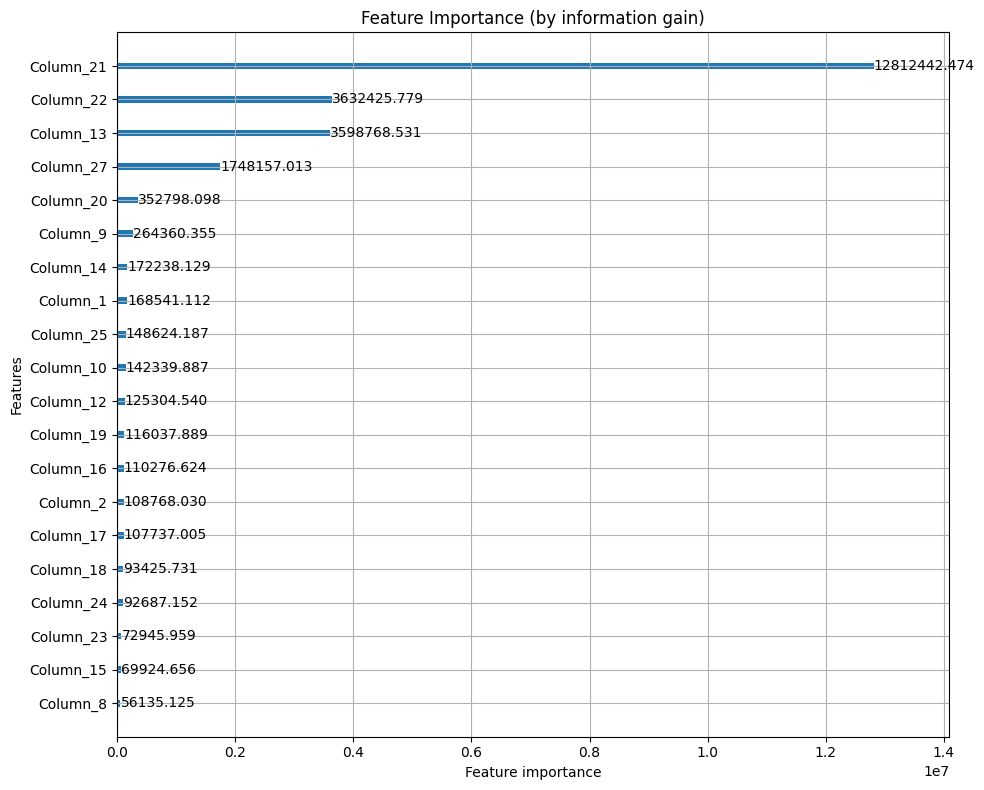


Top 12 features:
  price_ratio          ██████████████████████████████
  item_dow_avg         ████████████████
  sdow_lag6            ██████████
  sdow_lag3            █████████
  sdow_lag1            ████████
  month                ████████
  sdow_lag5            ████████
  sdow_lag4            ████████
  sdow_ma6             ███████
  item_std_qty         ███████
  sdow_ma4             ███████
  sdow_trend           ███████
  day_of_month         ███████
  item_max_qty         ███████
  item_pct_zero        ██████
  sdow_lag2            ██████
  sdow_ewma            ██████
  sdow_cv              █████
  cycle_on_special     █████
  item_avg_qty         ███
  item_avg_lines       ██
  dow                  ██
  is_friday            █
  season               █
  days_since_wed       
  is_holiday           
  is_price_sensitive   
  is_saturday          
  is_monday            


In [19]:
fig, ax = plt.subplots(figsize=(10, 8))
lgb.plot_importance(model, ax=ax, importance_type='gain', max_num_features=20,
                     title='Feature Importance (by information gain)')
plt.tight_layout()
plt.show()

importances = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 12 features:")
for _, row in importances.head(29).iterrows():
    bar = "█" * int(row['importance'] / importances['importance'].max() * 30)
    print(f"  {row['feature']:<20} {bar}")

## 10. Expanding Window Backtest

In [10]:
N_BACKTEST = min(6, len(clean_cycles) - 2)
backtest_results = []

print(f"Running expanding-window backtest on {N_BACKTEST} non-holiday cycles...")
print("-" * 60)

for i in range(N_BACKTEST):
    cycle_idx = len(clean_cycles) - N_BACKTEST + i
    test_cycle = clean_cycles[cycle_idx]

    bt_train = model_data[model_data['Date'] < min(test_cycle)]
    bt_test = model_data[model_data['Date'].isin(test_cycle)]

    if len(bt_train) < 1000 or len(bt_test) == 0:
        continue

    X_bt_train = bt_train[feature_cols].values.astype(float)
    y_bt_train = bt_train['qty'].values.astype(float)
    X_bt_test = bt_test[feature_cols].values.astype(float)
    y_bt_test = bt_test['qty'].values.astype(float)

    bt_model = lgb.LGBMRegressor(**{**params, 'n_estimators': 300})
    bt_model.fit(X_bt_train, y_bt_train, eval_set=[(X_bt_test, y_bt_test)],
                 eval_metric='mae', callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(0)])

    bt_pred = np.maximum(bt_model.predict(X_bt_test), 0)
    mae = mean_absolute_error(y_bt_test, bt_pred)
    wmape = np.sum(np.abs(y_bt_test - bt_pred)) / max(y_bt_test.sum(), 1) * 100
    bias = (bt_pred.sum() - y_bt_test.sum()) / max(y_bt_test.sum(), 1) * 100

    cycle_label = f"{min(test_cycle).date()} to {max(test_cycle).date()}"
    print(f"  Cycle {i+1}: {cycle_label}  MAE={mae:.2f}  WMAPE={wmape:.1f}%  Bias={bias:+.1f}%")
    backtest_results.append({'cycle': cycle_label, 'mae': mae, 'wmape': wmape, 'bias': bias})

bt_df = pd.DataFrame(backtest_results)
print(f"\nBACKTEST SUMMARY ({len(bt_df)} non-holiday cycles)")
print(f"  WMAPE: {bt_df['wmape'].mean():.1f}% ± {bt_df['wmape'].std():.1f}%")
print(f"  MAE:   {bt_df['mae'].mean():.2f} ± {bt_df['mae'].std():.2f}")
print(f"  Bias:  {bt_df['bias'].mean():+.1f}% ± {bt_df['bias'].std():.1f}%")

Running expanding-window backtest on 6 non-holiday cycles...
------------------------------------------------------------
  Cycle 1: 2026-02-13 to 2026-02-16  MAE=0.94  WMAPE=31.4%  Bias=-3.6%
  Cycle 2: 2026-02-20 to 2026-02-23  MAE=1.14  WMAPE=39.0%  Bias=+2.4%
  Cycle 3: 2026-02-27 to 2026-03-02  MAE=1.17  WMAPE=43.0%  Bias=+8.3%
  Cycle 4: 2026-03-13 to 2026-03-16  MAE=0.93  WMAPE=37.4%  Bias=+6.5%
  Cycle 5: 2026-03-20 to 2026-03-23  MAE=1.16  WMAPE=41.7%  Bias=+2.2%
  Cycle 6: 2026-03-27 to 2026-03-30  MAE=1.04  WMAPE=38.6%  Bias=-2.9%

BACKTEST SUMMARY (6 non-holiday cycles)
  WMAPE: 38.5% ± 4.1%
  MAE:   1.06 ± 0.11
  Bias:  +2.1% ± 4.8%


## 11. Retrain Final Model on All Data

In [11]:
X_all = model_data[feature_cols].values.astype(float)
y_all = model_data['qty'].values.astype(float)

final_model = lgb.LGBMRegressor(**{**params, 'n_estimators': model.best_iteration_ or 300})
final_model.fit(X_all, y_all)

print(f"Final model trained on {len(X_all):,} rows")
print(f"Trees: {final_model.n_estimators}")

Final model trained on 71,442 rows
Trees: 146


## 12. Load Specials & Configure Order Cycle

**Specials:** Create a file called `specials_this_week.csv` with columns `cycle_start` and `Name`.
Add entries for upcoming cycles so the model picks them up automatically.
If the file doesn't exist, the model assumes no items are on special.

```
cycle_start,Name
2026-03-25,STRAWBERRIES PER PUNNET
2026-03-25,WATERMELON SEEDLESS PER KG
2026-03-27,BANANAS PER KG
```

The `cycle_start` date is the **order date** (Wednesday or Friday).

In [12]:
from datetime import timedelta

# ── Load specials (date-filtered) ──
specials_file = str(ROOT / '01_data/operational/specials_this_week.csv')
specials_this_cycle = []

if os.path.exists(specials_file):
    specials_df = pd.read_csv(specials_file)
    specials_df.columns = specials_df.columns.str.strip()

    if 'cycle_start' in specials_df.columns and 'Name' in specials_df.columns:
        specials_df['cycle_start'] = pd.to_datetime(specials_df['cycle_start'], errors='coerce')

        # Determine the order_date for this cycle (used for filtering)
        today = pd.Timestamp.today().normalize()
        today_dow = today.weekday()
        if ORDER_CYCLE == 'wednesday':
            days_to_order = (2 - today_dow) % 7
        else:
            days_to_order = (4 - today_dow) % 7
        cycle_order_date = today + timedelta(days=days_to_order)

        mask = specials_df['cycle_start'] == cycle_order_date
        specials_this_cycle = specials_df.loc[mask, 'Name'].tolist()
        print(f"Specials for cycle starting {cycle_order_date.date()}: {len(specials_this_cycle)} items")

        # Also show upcoming specials for reference
        future = specials_df[specials_df['cycle_start'] > cycle_order_date]
        if len(future) > 0:
            upcoming = future.groupby('cycle_start')['Name'].count()
            print(f"Upcoming specials scheduled: {len(upcoming)} future cycle(s)")
    elif 'Name' in specials_df.columns:
        # Backwards compatible: no date column, load all
        specials_this_cycle = specials_df['Name'].tolist()
        print(f"Specials loaded (no date filter): {len(specials_this_cycle)} items")
    else:
        print(f"⚠️  specials CSV has unexpected columns: {list(specials_df.columns)}")

    for s in specials_this_cycle:
        print(f"  • {s}")
else:
    print(f"No specials file found ({specials_file}). Assuming no specials this cycle.")
    print("Create it with columns: cycle_start, Name")

# ── Define target dates ──
today = pd.Timestamp.today().normalize()
today_dow = today.weekday()

if ORDER_CYCLE == 'wednesday':
    days_to_order = (2 - today_dow) % 7
    order_date = today + timedelta(days=days_to_order)
    delivery_date = order_date + timedelta(days=2)

    depletion_days = {
        'Wed afternoon': (order_date, order_date.weekday(), WEEKDAY_AFTERNOON_FRACTION),
        'Thursday':      (order_date + timedelta(days=1), (order_date + timedelta(days=1)).weekday(), 1.0),
    }
    coverage_days = {
        'Friday':   (delivery_date, delivery_date.weekday(), 1.0),
        'Saturday': (delivery_date + timedelta(days=1), (delivery_date + timedelta(days=1)).weekday(), 1.0),
        'Monday':   (delivery_date + timedelta(days=3), (delivery_date + timedelta(days=3)).weekday(), 1.0),
    }

elif ORDER_CYCLE == 'friday':
    days_to_order = (4 - today_dow) % 7
    order_date = today + timedelta(days=days_to_order)
    delivery_date = order_date + timedelta(days=4)

    depletion_days = {
        'Fri afternoon': (order_date, order_date.weekday(), WEEKDAY_AFTERNOON_FRACTION),
        'Saturday':      (order_date + timedelta(days=1), (order_date + timedelta(days=1)).weekday(), 1.0),
        'Monday':        (order_date + timedelta(days=3), (order_date + timedelta(days=3)).weekday(), 1.0),
    }
    coverage_days = {
        'Tuesday':   (delivery_date, delivery_date.weekday(), 1.0),
        'Wednesday': (delivery_date + timedelta(days=1), (delivery_date + timedelta(days=1)).weekday(), 1.0),
        'Thursday':  (delivery_date + timedelta(days=2), (delivery_date + timedelta(days=2)).weekday(), 1.0),
    }

# Check for holidays in this cycle
all_cycle_dates = [d for _, (d, _, _) in {**depletion_days, **coverage_days}.items()]
holidays_in_cycle = [d for d in all_cycle_dates if d in PUBLIC_HOLIDAYS]
if holidays_in_cycle:
    print(f"\n⚠️  PUBLIC HOLIDAY in this cycle: {[d.date() for d in holidays_in_cycle]}")
    print("   Those days will be predicted as 0 demand (store closed).")

print(f"\nOrder: {order_date.strftime('%A %d %B')} | Delivery: {delivery_date.strftime('%A %d %B')}")
print("\nDEPLETION:")
for name, (d, dow, m) in depletion_days.items():
    h = " [HOLIDAY]" if d in PUBLIC_HOLIDAYS else ""
    print(f"  {name:<18} {d.date()} ({d.strftime('%A')}) ×{m:.2f}{h}")
print("COVERAGE:")
for name, (d, dow, m) in coverage_days.items():
    h = " [HOLIDAY]" if d in PUBLIC_HOLIDAYS else ""
    print(f"  {name:<18} {d.date()} ({d.strftime('%A')}) ×{m:.2f}{h}")

Specials for cycle starting 2026-04-22: 0 items

⚠️  PUBLIC HOLIDAY in this cycle: [datetime.date(2026, 4, 25)]
   Those days will be predicted as 0 demand (store closed).

Order: Wednesday 22 April | Delivery: Friday 24 April

DEPLETION:
  Wed afternoon      2026-04-22 (Wednesday) ×0.42
  Thursday           2026-04-23 (Thursday) ×1.00
COVERAGE:
  Friday             2026-04-24 (Friday) ×1.00
  Saturday           2026-04-25 (Saturday) ×1.00 [HOLIDAY]
  Monday             2026-04-27 (Monday) ×1.00


## 13. Generate Predictions

In [13]:
all_target_days = {**depletion_days, **coverage_days}
predictions = []

for item in active_items:
    item_daily = daily_full[daily_full['Name'] == item]
    istats_row = item_stats[item_stats['Name'] == item]
    if len(istats_row) == 0:
        continue
    istats = istats_row.iloc[0]

    for day_name, (tgt_date, dow, multiplier) in all_target_days.items():

        # If this day is a public holiday, predict 0
        if tgt_date in PUBLIC_HOLIDAYS:
            predictions.append({
                'Name': item, 'day_name': day_name, 'date': tgt_date, 'dow': dow,
                'type': 'coverage' if day_name in coverage_days else 'depletion',
                'full_day_pred': 0, 'multiplier': 0, 'adjusted_pred': 0,
            })
            continue

        # Same-weekday history
        same_dow = item_daily[item_daily['dow'] == dow].sort_values('Date')
        qtys = same_dow['qty'].values

        # Lag features
        lags = [qtys[-(i+1)] if len(qtys) > i else np.nan for i in range(6)]

        valid_lags = [l for l in lags[:4] if not np.isnan(l)]
        ma4 = np.mean(valid_lags) if len(valid_lags) >= 2 else istats['item_avg_qty']
        valid_lags6 = [l for l in lags if not np.isnan(l)]
        ma6 = np.mean(valid_lags6) if len(valid_lags6) >= 2 else ma4

        # EWMA
        ew_weights = np.array([alpha ** i for i in range(6)])
        ew_weights = ew_weights / ew_weights.sum()
        avail = np.array([not np.isnan(l) for l in lags])
        if avail.any():
            ewma = np.dot(ew_weights * avail, np.nan_to_num(np.array(lags), nan=0.0)) / np.dot(ew_weights, avail)
        else:
            ewma = istats['item_avg_qty']

        cv = np.std(valid_lags) / max(np.mean(valid_lags), 0.1) if len(valid_lags) >= 3 else 1.0
        cv = min(cv, 5.0)
        trend = (lags[0] - lags[1]) if len(valid_lags) >= 2 and not np.isnan(lags[0]) and not np.isnan(lags[1]) else 0

        idow = item_dow[(item_dow['Name'] == item) & (item_dow['dow'] == dow)]
        idow_avg = idow['item_dow_avg'].values[0] if len(idow) > 0 else istats['item_avg_qty']

        is_special = 1 if item in specials_this_cycle else 0

        row_features = {
            'dow': dow, 'month': tgt_date.month, 'day_of_month': tgt_date.day,
            'days_since_wed': (dow - 2) % 7,
            'is_saturday': int(dow == 5), 'is_friday': int(dow == 4), 'is_monday': int(dow == 0),
            'is_holiday': int(tgt_date in PUBLIC_HOLIDAYS),
            'item_avg_qty': istats['item_avg_qty'], 'item_std_qty': istats['item_std_qty'],
            'item_max_qty': istats['item_max_qty'], 'item_avg_lines': istats['item_avg_lines'],
            'item_pct_zero': istats['item_pct_zero'], 'item_dow_avg': idow_avg,
            'sdow_lag1': lags[0] if not np.isnan(lags[0]) else 0,
            'sdow_lag2': lags[1] if not np.isnan(lags[1]) else 0,
            'sdow_lag3': lags[2] if not np.isnan(lags[2]) else 0,
            'sdow_lag4': lags[3] if not np.isnan(lags[3]) else 0,
            'sdow_lag5': lags[4] if not np.isnan(lags[4]) else 0,
            'sdow_lag6': lags[5] if not np.isnan(lags[5]) else 0,
            'sdow_ma4': ma4, 'sdow_ma6': ma6, 'sdow_ewma': ewma,
            'sdow_cv': cv, 'sdow_trend': trend,
            'cycle_on_special': is_special, 'season': season_map.get(tgt_date.month, 2)
        }

        # ── Choose forecast model ──────────────────────────────────
        if USE_MODEL == 'ewma':
            pred_qty = max(0, ewma)
        else:  # 'lgbm'
            x_vec = np.array([[row_features[c] for c in feature_cols]])
            pred_qty = max(0, final_model.predict(x_vec)[0])
        adjusted_qty = pred_qty * multiplier

        predictions.append({
            'Name': item, 'day_name': day_name, 'date': tgt_date, 'dow': dow,
            'type': 'coverage' if day_name in coverage_days else 'depletion',
            'full_day_pred': pred_qty, 'multiplier': multiplier, 'adjusted_pred': adjusted_qty,
        })

pred_df = pd.DataFrame(predictions)

# Summary
n_special_items = pred_df[pred_df['Name'].isin(specials_this_cycle)]['Name'].nunique()
n_holiday_days = (pred_df['adjusted_pred'] == 0).sum() - (pred_df['full_day_pred'] == 0).sum()
print(f"Predictions: {len(pred_df):,} ({len(active_items)} items × {len(all_target_days)} days)")
print(f"Items on special: {n_special_items}")
if holidays_in_cycle:
    print(f"Holiday days (predicted as 0): {len(holidays_in_cycle)}")

Predictions: 945 (189 items × 5 days)
Items on special: 0
Holiday days (predicted as 0): 1


## 14. Build Order List

**Stock on Hand:** Create `stock_on_hand_v2.csv` with columns `Name` and `Stock`.
Fill in the `Stock` column with your manual count before running the order.
Item names are pre-cleaned (no embedded newlines from POS).

```
Name,Stock
BANANAS PER KG,45
STRAWBERRIES PER PUNNET,12
LETTUCE           PER EACH,30
```

If the file doesn't exist, stock defaults to 0 for all items.

In [14]:
# ── Load stock on hand ──
# Helper: clean item name (remove embedded newlines from POS export)
def clean_name(n):
    return str(n).replace('\n', ' ').replace('\r', ' ').strip()

stock_file = str(ROOT / '01_data/operational/stock_on_hand_v2.csv')

if os.path.exists(stock_file):
    stock_df = pd.read_csv(stock_file)
    stock_df['Name'] = stock_df['Name'].apply(clean_name)
    stock_dict = dict(zip(stock_df['Name'], stock_df['Stock']))
    print(f"Stock on hand loaded from {stock_file}: {len(stock_dict)} items, {sum(stock_dict.values()):.0f} total units")
else:
    stock_dict = {}
    print("No stock file found. Using 0 for all items.")
    print("Create stock_on_hand_v2.csv with 'Name' and 'Stock' columns.")

# ── Aggregate ──
coverage_demand = pred_df[pred_df['type'] == 'coverage'].groupby('Name')['adjusted_pred'].sum()
depletion_demand = pred_df[pred_df['type'] == 'depletion'].groupby('Name')['adjusted_pred'].sum()

order = pd.DataFrame({
    'coverage_total': np.ceil(coverage_demand).astype(int),
    'depletion_total': np.ceil(depletion_demand).astype(int),
}).fillna(0).astype(int)

order['stock_on_hand'] = order.index.map(lambda x: stock_dict.get(clean_name(x), stock_dict.get(x, 0)))
order['order_qty'] = (order['coverage_total'] + order['depletion_total'] - order['stock_on_hand']).clip(lower=0)

# Metadata
item_meta = clean[clean['Name'].isin(active_items)].groupby('Name').agg(
    subdept=('Sub Department Name', 'first'),
    total_rev=('Sales Ex GST', 'sum'),
).reset_index().set_index('Name')

order = order.join(item_meta)
order['subdept'] = order['subdept'].fillna('Other')
order = order[order['order_qty'] > 0]
order = order.sort_values(['subdept', 'total_rev'], ascending=[True, False])

# Flag specials in the output
order['on_special'] = order.index.isin(specials_this_cycle)

print(f"\nItems on order: {len(order)}")
print(f"  Coverage demand:  {order['coverage_total'].sum():>6} units")
print(f"  Depletion demand: {order['depletion_total'].sum():>6} units")
print(f"  Stock deducted:   {order['stock_on_hand'].sum():>6} units")
print(f"  ─────────────────────────")
print(f"  ORDER TOTAL:      {order['order_qty'].sum():>6} units")
if order['on_special'].any():
    print(f"\n  ★ Items on special: {order['on_special'].sum()}")

Stock on hand loaded from C:\Users\fabio\OneDrive\Documentos\foodland_wudinna\01_data\operational\stock_on_hand_v2.csv: 182 items, 398 total units

Items on order: 157
  Coverage demand:    1140 units
  Depletion demand:    675 units
  Stock deducted:       64 units
  ─────────────────────────
  ORDER TOTAL:        1751 units


In [15]:
# ── Print order list ──
sep = "=" * 85
print(sep)
print(f"  ORDER LIST — {order_date.strftime('%A %d %B')} | Delivery {delivery_date.strftime('%A %d %B')}")
print(sep)
print(f"  {'Item':<38} {'Cover':>7} {'Deplet':>7} {'Stock':>7} {'ORDER':>7}")
print(f"  {'─'*38} {'─'*7} {'─'*7} {'─'*7} {'─'*7}")

current_dept = None
dept_total = 0

for item, row in order.iterrows():
    sd = row['subdept']
    if sd != current_dept:
        if current_dept is not None:
            print(f"  {'─'*38} {'─'*7} {'─'*7} {'─'*7} {'─'*7}")
            print(f"  {current_dept + ' subtotal':<38} {'':>7} {'':>7} {'':>7} {dept_total:>7}")
            print()
        current_dept = sd
        dept_total = 0
        print(f"  ┌─ {sd.upper()} {'─' * (78 - len(sd))}")

    name = item.replace('\n', ' ').strip()[:36]
    star = " ★" if row['on_special'] else ""
    print(f"  │ {name:<36}{star:>2} {row['coverage_total']:>7} {row['depletion_total']:>7} {row['stock_on_hand']:>7} {row['order_qty']:>7}")
    dept_total += row['order_qty']

print(f"  {'─'*38} {'─'*7} {'─'*7} {'─'*7} {'─'*7}")
print(f"  {current_dept + ' subtotal':<38} {'':>7} {'':>7} {'':>7} {dept_total:>7}")
print()
print(sep)
print(f"  {'GRAND TOTAL':<38} {order['coverage_total'].sum():>7} {order['depletion_total'].sum():>7} {order['stock_on_hand'].sum():>7} {order['order_qty'].sum():>7}")
print(sep)
if order['on_special'].any():
    print("  ★ = item on special this cycle")

  ORDER LIST — Wednesday 22 April | Delivery Friday 24 April
  Item                                     Cover  Deplet   Stock   ORDER
  ────────────────────────────────────── ─────── ─────── ─────── ───────
  ┌─ FRUIT ─────────────────────────────────────────────────────────────────────────
  │ BANANAS PER KG                              79      32       0     111
  │ STRAWBERRIES PER PUNNET                     54      23       0      77
  │ WATERMELON SEEDLESS PER KG                  60      26       0      86
  │ APPLES PINK LADY PER KG                     24      10       0      34
  │ GRAPES GREEN PER KG                         35      21       0      56
  │ AVOCADO  PER EACH                           36      27       0      63
  │ TOMATOES - MINI ROMA 200GM PUNNET           26      15       0      41
  │ TOMATOES TRUSS LOOSE PER KG                 12       9       0      21
  │ TOMATOES - PREPACK 500G                     10       6       0      16
  │ GRAPES DARK PER KG           

## 15. Export to Excel

In [16]:
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

NAVY_C = "1B4F72"; GREEN_C = "1A7A44"; LGRAY_C = "F2F4F5"; WHITE_C = "FFFFFF"

wb = Workbook()
ws = wb.active
ws.title = "Order List"

for i, w in enumerate([38, 8, 8, 8, 9], 1):
    ws.column_dimensions[get_column_letter(i)].width = w

brd = Border(left=Side("thin","CCCCCC"), right=Side("thin","CCCCCC"),
             top=Side("thin","CCCCCC"), bottom=Side("thin","CCCCCC"))
ctr = Alignment(horizontal="center", vertical="center")
hfont = Font("Arial", 9, bold=True, color=WHITE_C)
hfill = PatternFill("solid", fgColor=NAVY_C)
bfont = Font("Arial", 9)
bfontb = Font("Arial", 9, bold=True)

ws.merge_cells("A1:E1")
ws["A1"].value = f"ORDER LIST — {order_date.strftime('%A %d %b')} | Delivery {delivery_date.strftime('%A %d %b')}"
ws["A1"].font = Font("Arial", 12, bold=True, color=NAVY_C)
ws.merge_cells("A2:E2")
cov_str = ", ".join([f"{d.strftime('%A %d')}" for _, (d,_,_) in coverage_days.items()])
dep_str = ", ".join([f"{d.strftime('%A %d')}" for _, (d,_,_) in depletion_days.items()])
ws["A2"].value = f"Coverage: {cov_str} | Depletion: {dep_str}"
ws["A2"].font = Font("Arial", 8, color="666666")

for i, h in enumerate(["Item", "Coverage", "Depletion", "Stock", "ORDER"], 1):
    c = ws.cell(4, i, h); c.font = hfont; c.fill = hfill; c.alignment = ctr; c.border = brd

rn = 5
current_dept = None
for item, rd in order.iterrows():
    sd = rd['subdept']
    if sd != current_dept:
        current_dept = sd
        ws.merge_cells(f"A{rn}:E{rn}")
        c = ws.cell(rn, 1, sd.upper())
        c.font = Font("Arial", 10, bold=True, color=NAVY_C)
        c.fill = PatternFill("solid", fgColor="D5E8F0")
        for col in range(1, 6): ws.cell(rn, col).border = brd
        rn += 1

    name = item.replace('\n', ' ').strip()[:40]
    if rd['on_special']: name += " ★"
    ws.cell(rn, 1, name).font = bfont
    for ci, val in [(2, rd['coverage_total']), (3, rd['depletion_total']),
                     (4, rd['stock_on_hand']), (5, rd['order_qty'])]:
        ws.cell(rn, ci, int(val)).font = bfontb if ci == 5 else bfont
        ws.cell(rn, ci).alignment = ctr
    for col in range(1, 6):
        ws.cell(rn, col).border = brd
        if rn % 2 == 0: ws.cell(rn, col).fill = PatternFill("solid", fgColor=LGRAY_C)
    rn += 1

rn += 1
tfill = PatternFill("solid", fgColor=GREEN_C)
tfont = Font("Arial", 10, bold=True, color=WHITE_C)
ws.cell(rn, 1, "GRAND TOTAL").font = tfont; ws.cell(rn, 1).fill = tfill
for ci, val in [(2, order['coverage_total'].sum()), (3, order['depletion_total'].sum()),
                 (4, order['stock_on_hand'].sum()), (5, order['order_qty'].sum())]:
    ws.cell(rn, ci, int(val)).font = tfont; ws.cell(rn, ci).fill = tfill; ws.cell(rn, ci).alignment = ctr
for col in range(1, 6): ws.cell(rn, col).border = brd

rn += 2
ws.merge_cells(f"A{rn}:E{rn}")
bt_w = bt_df['wmape'].mean() if len(bt_df) > 0 else lgbm_test_m['wmape']
ws.cell(rn, 1, f"Model: LightGBM | Backtest WMAPE: {bt_w:.1f}% | Rounded UP. Adjust for stock on hand.").font = Font("Arial", 7, color="999999")
if order['on_special'].any():
    rn += 1; ws.merge_cells(f"A{rn}:E{rn}")
    ws.cell(rn, 1, "★ = item on special this cycle").font = Font("Arial", 7, color="999999")

output_file = ROOT / f"04_ordering/FruitVeg_Order_{order_date.strftime('%Y%m%d')}.xlsx"
wb.save(str(output_file))
print(f"Order list saved: {output_file}")

Order list saved: C:\Users\fabio\OneDrive\Documentos\foodland_wudinna\04_ordering\FruitVeg_Order_20260422.xlsx


## 16. Actual vs Predicted (Test Set)

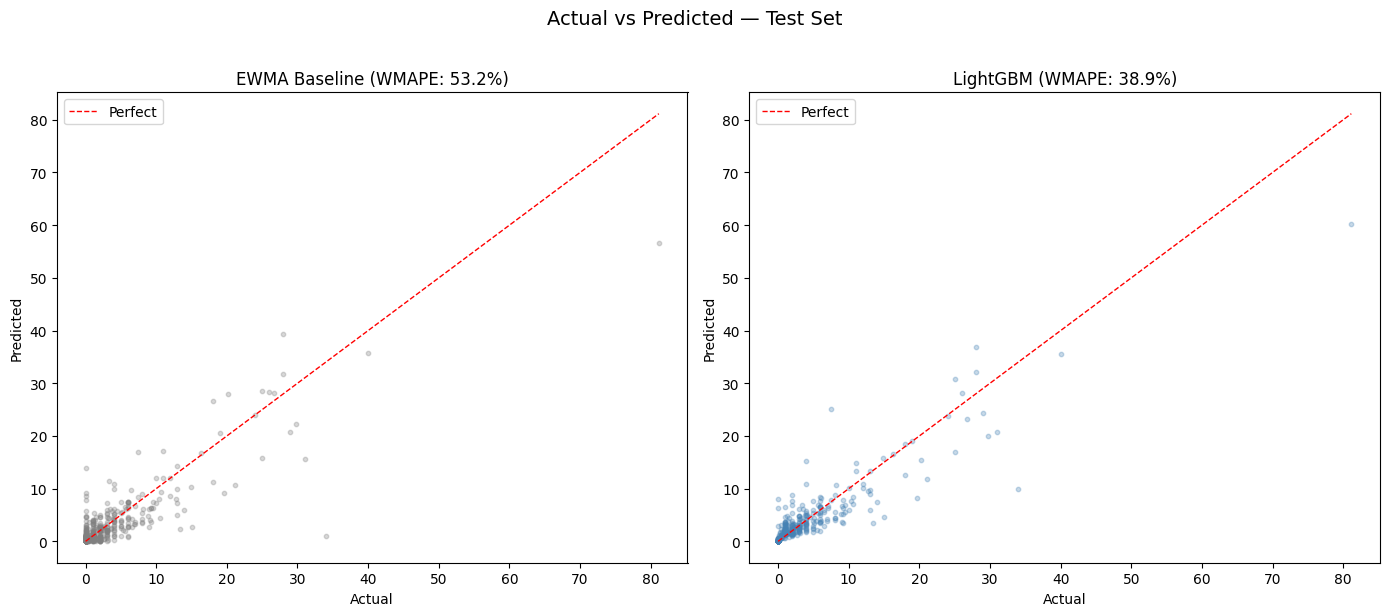

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
ax.scatter(y_test, np.maximum(ewma_test, 0), alpha=0.3, s=10, color='gray')
ax.plot([0, y_test.max()], [0, y_test.max()], 'r--', lw=1, label='Perfect')
ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
ax.set_title(f'EWMA Baseline (WMAPE: {ewma_test_m["wmape"]:.1f}%)')
ax.legend()

ax = axes[1]
ax.scatter(y_test, np.maximum(lgbm_test_pred, 0), alpha=0.3, s=10, color='steelblue')
ax.plot([0, y_test.max()], [0, y_test.max()], 'r--', lw=1, label='Perfect')
ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
ax.set_title(f'LightGBM (WMAPE: {lgbm_test_m["wmape"]:.1f}%)')
ax.legend()

plt.suptitle('Actual vs Predicted — Test Set', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 17. Save Model

In [18]:
import pickle

model_export = {
    'model': final_model,
    'feature_cols': feature_cols,
    'item_stats': item_stats,
    'item_dow': item_dow,
    'active_items': active_items,
    'alpha': alpha,
    'season_map': season_map,
    'daily_full': daily_full,
    'public_holidays': PUBLIC_HOLIDAYS,
    'trained_on': pd.Timestamp.today().date(),
}

model_out = ROOT / '03_model/demand_model.pkl'
with open(model_out, 'wb') as f:
    pickle.dump(model_export, f)

print(f"Model saved: {model_out}")
print("Retrain weekly when you get new POS data for best accuracy.")

Model saved: C:\Users\fabio\OneDrive\Documentos\foodland_wudinna\03_model\demand_model.pkl
Retrain weekly when you get new POS data for best accuracy.
